In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# Dimensionality Reduction

## Data Loading and Data Preparation

In [2]:
# Load the Labeled Faces in the Wild dataset
lfw_people = fetch_lfw_people(min_faces_per_person=30, resize=0.5)

# Extract data
X = lfw_people.data  # Flattened image data
y = lfw_people.target  # Labels (person IDs)
target_names = lfw_people.target_names  # Names of people
images = lfw_people.images  # Original image shape

In [3]:
# Report dataset information
n_samples, h, w = images.shape
n_people = len(target_names)

print("=" * 50)
print("Labeled Faces in the Wild Dataset Summary")
print("=" * 50)
print(f"Number of different people: {n_people}")
print(f"Number of images: {n_samples}")
print(f"Image size: {h} x {w} pixels")
print("=" * 50)

Labeled Faces in the Wild Dataset Summary
Number of different people: 34
Number of images: 2370
Image size: 62 x 47 pixels


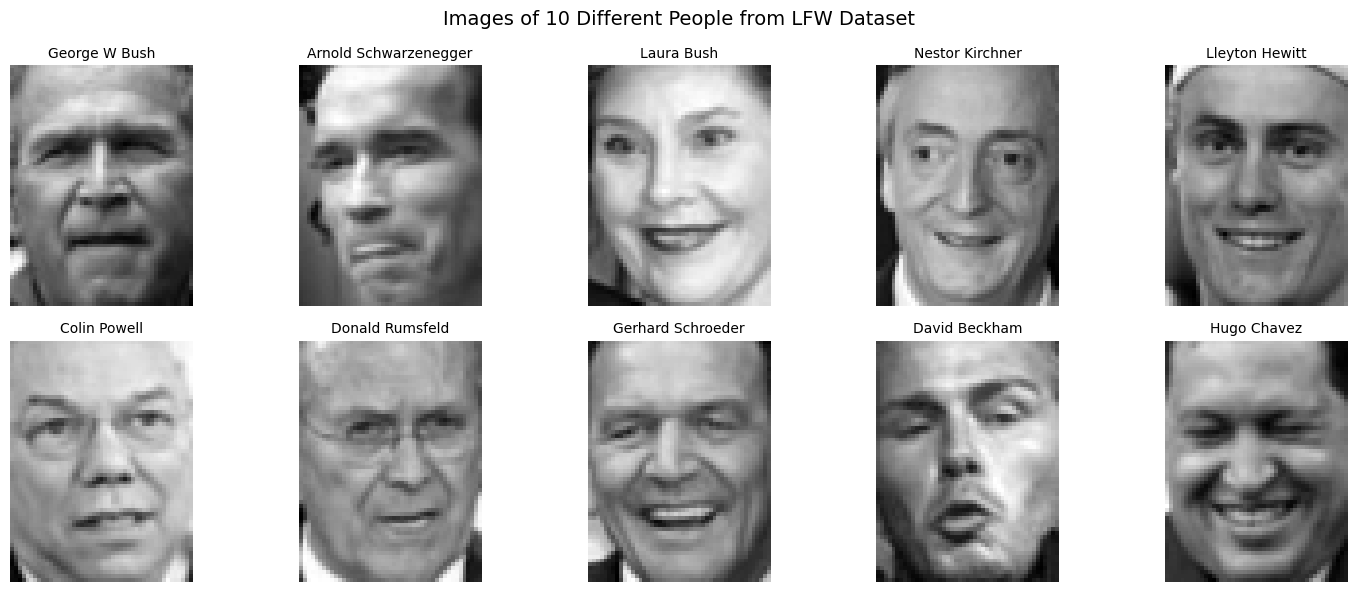

In [ ]:
# Plot images of ten different people
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Get indices for one image of each of the first 10 different people
people_indices = []
people_names = set()

for idx, label in enumerate(y):
    if label not in people_names:
        people_indices.append(idx)
        people_names.add(label)
    if len(people_indices) == 10:
        break

# Plot the images
for i, idx in enumerate(people_indices):
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(target_names[y[idx]], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Images of 10 Different People from LFW Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Split the data into 70% training and 30% validation (stratified)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("=" * 50)
print("Train/Validation Split Summary")
print("=" * 50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print("=" * 50)

Train/Validation Split Summary
Training set size: 1659 samples
Validation set size: 711 samples
Training set shape: (1659, 2914)
Validation set shape: (711, 2914)


## Dimensionality Reduction Using PCA

In [6]:
class PCA:
    # Principal Component Analysis (PCA) implementation.
    
    def __init__(self, n_components):
        # Initialize PCA with the number of principal components to keep.
        self.n_components = n_components
        self.components_ = None  # Principal components (eigenvectors)
        self.mean_ = None  # Mean of the training data
        self.explained_variance_ = None  # Variance explained by each component
        self.explained_variance_ratio_ = None  # Percentage of variance explained
    
    def fit(self, X):
        # Fit the PCA model to the data using SVD.
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        
        n_samples = X.shape[0]
        self.explained_variance_ = (S[:self.n_components] ** 2) / (n_samples - 1)
        total_variance = np.sum(S ** 2) / (n_samples - 1)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
    
    def transform(self, X):
        # Project data onto the principal components.
        X_centered = X - self.mean_
        return X_centered @ self.components_.T
    
    def inverse_transform(self, X_projected):
        # Reconstruct data from the principal component representation.
        return X_projected @ self.components_ + self.mean_


In [7]:
# Fit PCA for different numbers of principal components
n_components_list = [5, 10, 20, 40, 80, 160, 320, 640]

# Dictionary to store fitted PCA models and projections
pca_models = {}
X_train_projected = {}
X_val_projected = {}

for d in n_components_list:
    # Fit PCA on training data
    pca = PCA(n_components=d)
    pca.fit(X_train)
    
    # Store the model
    pca_models[d] = pca
    
    # Project training and validation data
    X_train_projected[d] = pca.transform(X_train)
    X_val_projected[d] = pca.transform(X_val)
    
    # Report explained variance
    cumulative_variance = np.sum(pca.explained_variance_ratio_) * 100
    print(f"d={d:3d}: Explained variance = {cumulative_variance:.2f}%")

d=  5: Explained variance = 52.69%
d= 10: Explained variance = 62.74%
d= 20: Explained variance = 72.88%
d= 40: Explained variance = 81.02%
d= 80: Explained variance = 88.24%
d=160: Explained variance = 93.94%
d=320: Explained variance = 97.66%
d=640: Explained variance = 99.46%


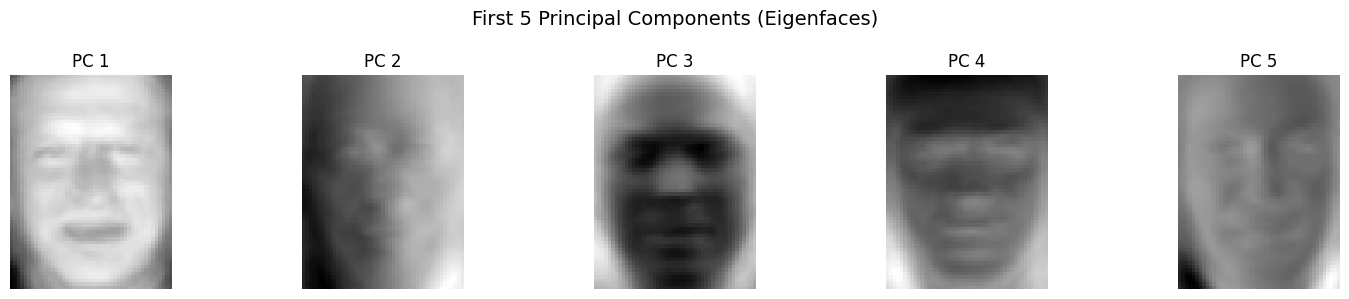

In [8]:
# Plot the first 5 principal components as images (eigenfaces)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Use PCA with highest number of components to get eigenfaces
pca_full = pca_models[640]

for i in range(5):
    # Reshape the principal component to image dimensions
    eigenface = pca_full.components_[i].reshape(h, w)
    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f'PC {i+1}')
    axes[i].axis('off')

plt.suptitle('First 5 Principal Components (Eigenfaces)', fontsize=14)
plt.tight_layout()
plt.show()

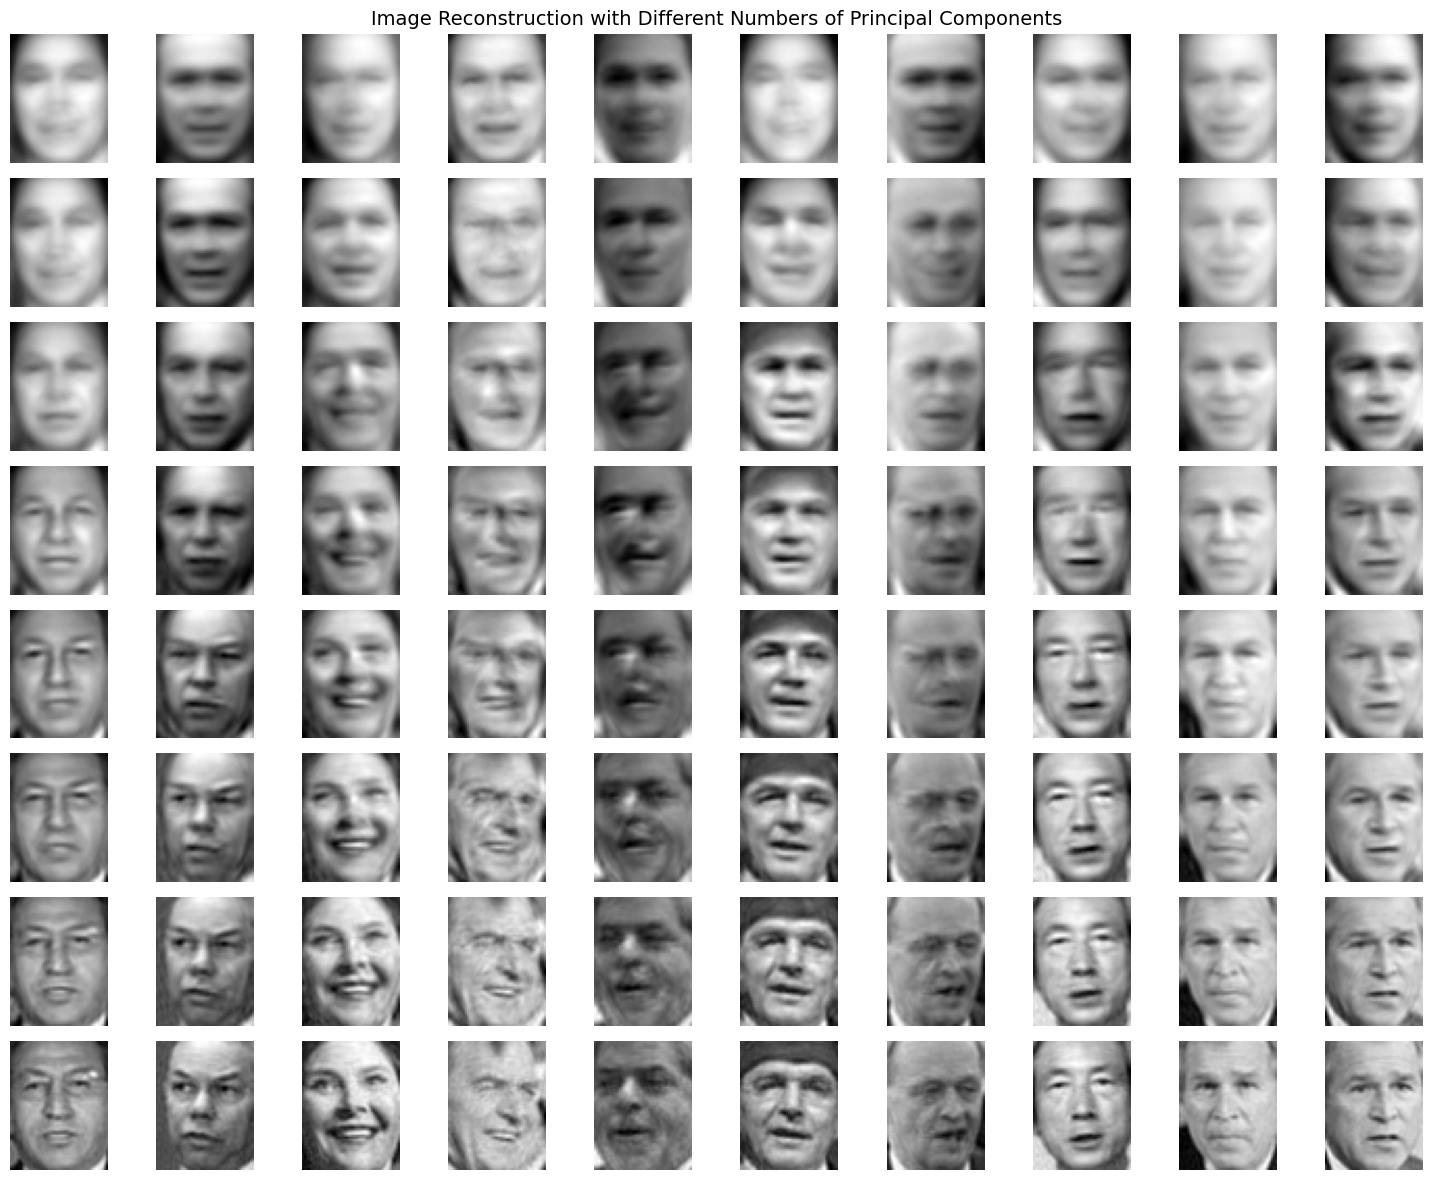

In [12]:
# Visualize 10 reconstructed images for each d
fig, axes = plt.subplots(len(n_components_list), 10, figsize=(15, 12))

# Select 10 random validation images to reconstruct
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 10, replace=False)

# Reconstruct images for each d
for i, d in enumerate(n_components_list):
    pca = pca_models[d]
    
    for j, idx in enumerate(sample_indices):
        # Project and reconstruct
        X_proj = pca.transform(X_val[idx:idx+1])
        X_recon = pca.inverse_transform(X_proj)
        
        # Display reconstructed image
        axes[i, j].imshow(X_recon.reshape(h, w), cmap='gray')
        axes[i, j].axis('off')

plt.suptitle('Image Reconstruction with Different Numbers of Principal Components', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Train logistic regression classifiers on projected data for each d
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Store models and results
lr_models = {}
scalers = {}
train_accuracies = {}
val_accuracies = {}

for d in n_components_list:
    # Normalize projected data using MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_projected[d])
    X_val_scaled = scaler.transform(X_val_projected[d])
    
    # Train logistic regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    
    # Store model and scaler
    lr_models[d] = lr
    scalers[d] = scaler
    
    # Compute accuracies
    train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
    val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
    
    train_accuracies[d] = train_acc
    val_accuracies[d] = val_acc
    
    print(f"d={d:3d}: Train Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")

d=  5: Train Accuracy = 0.2393, Validation Accuracy = 0.2391
d= 10: Train Accuracy = 0.2948, Validation Accuracy = 0.2827
d= 20: Train Accuracy = 0.3707, Validation Accuracy = 0.3418
d= 40: Train Accuracy = 0.5612, Validation Accuracy = 0.4824
d= 80: Train Accuracy = 0.7348, Validation Accuracy = 0.5556
d=160: Train Accuracy = 0.8662, Validation Accuracy = 0.5851
d=320: Train Accuracy = 0.9650, Validation Accuracy = 0.5612
d=640: Train Accuracy = 0.9988, Validation Accuracy = 0.5148


## Dimensionality Reduction Using Autoencoders

In [17]:
def encode(X, mlp):
    """
    This function is not working for general MLPs,
    the MLP must have the layer-configuration as
    stated in the exercise description.
    
    X must have the shape
    n_images x (witdh in pixels * height in pixels)
    """
    z = X
    for i in range(len(mlp.coefs_) // 2):
        z = z @ mlp.coefs_[i] + mlp.intercepts_[i]
        z = np.maximum(z, 0)
    
    return z

def decode(Z, mlp):
    """
    This function is not working for general MLPs, the MLP
    must have the layer-configuration as stated in the
    exercise description.
    
    Z must have the shape n_images x d
    """
    z = Z
    for i in range(len(mlp.coefs_) // 2, len(mlp.coefs_)):
        z = z @ mlp.coefs_[i] + mlp.intercepts_[i]
        if i < len(mlp.coefs_) - 1:
            z = np.maximum(z, 0)
    
    return z

In [19]:
# Train autoencoders for dimensionality reduction using MLPRegressor
from sklearn.neural_network import MLPRegressor

# Normalize input data for autoencoder training
scaler_ae = MinMaxScaler()
X_train_normalized = scaler_ae.fit_transform(X_train)
X_val_normalized = scaler_ae.transform(X_val)

# Autoencoder configurations: (a, b, d, b, a) with a=500, b=100
autoencoder_configs = {
    40: (500, 100, 40, 100, 500),   # a=500, b=100, d=40
    80: (500, 100, 80, 100, 500),   # a=500, b=100, d=80
}

# Store trained autoencoders
autoencoders = {}

for d, hidden_layers in autoencoder_configs.items():
    print(f"\nTraining autoencoder with d={d}, architecture: {hidden_layers}")
    
    # Create and train autoencoder
    ae = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    )
    
    # Train: input = output (reconstruction)
    ae.fit(X_train_normalized, X_train_normalized)
    
    # Store the model
    autoencoders[d] = ae
    
    print(f"  Training complete. Iterations: {ae.n_iter_}")


Training autoencoder with d=40, architecture: (500, 100, 40, 100, 500)
  Training complete. Iterations: 163

Training autoencoder with d=80, architecture: (500, 100, 80, 100, 500)
  Training complete. Iterations: 246


In [20]:
# Use autoencoders to project data onto reduced dimensions
X_train_ae_projected = {}
X_val_ae_projected = {}

for d in autoencoders.keys():
    ae = autoencoders[d]
    
    # Encode training and validation data
    X_train_ae_projected[d] = encode(X_train_normalized, ae)
    X_val_ae_projected[d] = encode(X_val_normalized, ae)
    
    # Compute reconstruction error
    X_train_recon = ae.predict(X_train_normalized)
    X_val_recon = ae.predict(X_val_normalized)
    
    train_mse = np.mean((X_train_normalized - X_train_recon) ** 2)
    val_mse = np.mean((X_val_normalized - X_val_recon) ** 2)
    
    print(f"d={d}:")
    print(f"  Encoded shape: {X_train_ae_projected[d].shape}")
    print(f"  Training MSE: {train_mse:.6f}")
    print(f"  Validation MSE: {val_mse:.6f}")

d=40:
  Encoded shape: (1659, 40)
  Training MSE: 0.008511
  Validation MSE: 0.009912
d=80:
  Encoded shape: (1659, 80)
  Training MSE: 0.006557
  Validation MSE: 0.008311


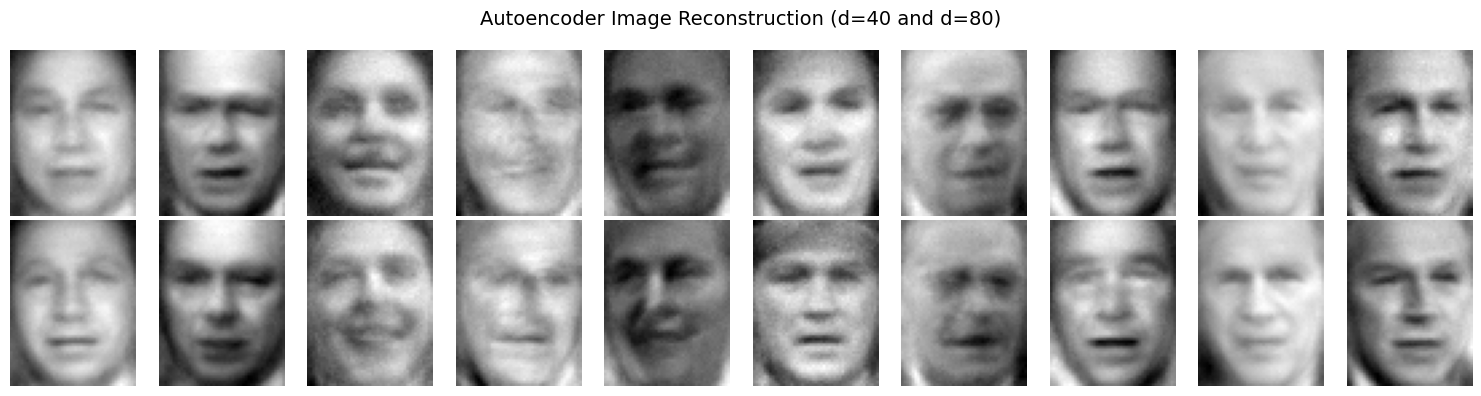

In [21]:
# Visualize 10 reconstructed images for each d using autoencoders
ae_dims = list(autoencoders.keys())
fig, axes = plt.subplots(len(ae_dims), 10, figsize=(15, 4))

# Use same sample indices as PCA for comparison
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), 10, replace=False)

for i, d in enumerate(ae_dims):
    ae = autoencoders[d]
    
    for j, idx in enumerate(sample_indices):
        # Encode and decode
        encoded = encode(X_val_normalized[idx:idx+1], ae)
        decoded = decode(encoded, ae)
        
        # Denormalize for display
        X_recon = scaler_ae.inverse_transform(decoded)
        
        # Display reconstructed image
        axes[i, j].imshow(X_recon.reshape(h, w), cmap='gray')
        axes[i, j].axis('off')
    
    axes[i, 0].set_ylabel(f'd={d}', fontsize=10)

plt.suptitle('Autoencoder Image Reconstruction (d=40 and d=80)', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Train logistic regression classifiers on autoencoder-projected data
lr_models_ae = {}
scalers_ae = {}
train_accuracies_ae = {}
val_accuracies_ae = {}

for d in autoencoders.keys():
    # Normalize projected data using MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_ae_projected[d])
    X_val_scaled = scaler.transform(X_val_ae_projected[d])
    
    # Train logistic regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    
    # Store model and scaler
    lr_models_ae[d] = lr
    scalers_ae[d] = scaler
    
    # Compute accuracies
    train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
    val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
    
    train_accuracies_ae[d] = train_acc
    val_accuracies_ae[d] = val_acc
    
    print(f"Autoencoder d={d}: Train Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")

Autoencoder d=40: Train Accuracy = 0.3309, Validation Accuracy = 0.2897
Autoencoder d=80: Train Accuracy = 0.4491, Validation Accuracy = 0.3882


In [24]:
# Compare PCA vs Autoencoder classification results
print("=" * 70)
print("Classification Accuracy Comparison: PCA vs Autoencoder")
print("=" * 70)

# PCA results
print("\nPCA Results:")
print("-" * 50)
print(f"{'d':>6} | {'Train Acc':>12} | {'Val Acc':>12}")
print("-" * 50)
for d in n_components_list:
    print(f"{d:>6} | {train_accuracies[d]:>12.4f} | {val_accuracies[d]:>12.4f}")

# Autoencoder results
print("\nAutoencoder Results:")
print("-" * 50)
print(f"{'d':>6} | {'Train Acc':>12} | {'Val Acc':>12}")
print("-" * 50)
for d in autoencoders.keys():
    print(f"{d:>6} | {train_accuracies_ae[d]:>12.4f} | {val_accuracies_ae[d]:>12.4f}")

Classification Accuracy Comparison: PCA vs Autoencoder

PCA Results:
--------------------------------------------------
     d |    Train Acc |      Val Acc
--------------------------------------------------
     5 |       0.2393 |       0.2391
    10 |       0.2948 |       0.2827
    20 |       0.3707 |       0.3418
    40 |       0.5612 |       0.4824
    80 |       0.7348 |       0.5556
   160 |       0.8662 |       0.5851
   320 |       0.9650 |       0.5612
   640 |       0.9988 |       0.5148

Autoencoder Results:
--------------------------------------------------
     d |    Train Acc |      Val Acc
--------------------------------------------------
    40 |       0.3309 |       0.2897
    80 |       0.4491 |       0.3882
